In [20]:
import sys, os

def find_backend_folder(start_path, max_levels=5):
    """Walks upward from start_path looking for a 'backend' folder."""
    current = os.path.abspath(start_path)
    for _ in range(max_levels):
        candidate = os.path.join(current, "backend")
        if os.path.isdir(candidate) and os.path.isfile(os.path.join(candidate, "app.py")):
            return candidate
        parent = os.path.dirname(current)
        if parent == current:
            break
        current = parent
    return None

backend_path = find_backend_folder(os.getcwd())

if backend_path is None:
    print("Could not auto-locate the backend folder.")
    print("Current working directory:", os.getcwd())
    print("Please set backend_path manually below.")
else:
    if backend_path not in sys.path:
        sys.path.insert(0, backend_path)
    print("Backend path found and added:", backend_path)

import pandas as pd
import numpy as np # type: ignore
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

from services.data_loader import load_prices, load_events

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 5)

print("All imports successful.")

Backend path found and added: /home/sumeya/Documents/ai project/brent-oil-change-point-analysis/backend
All imports successful.


In [21]:
prices = load_prices()
events = load_events()

print(f"Price data: {len(prices)} rows, {prices['Date'].min().date()} to {prices['Date'].max().date()}")
print(f"Events: {len(events)} rows")
prices.head()

Price data: 9011 rows, 1987-05-20 to 2022-11-14
Events: 15 rows


,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


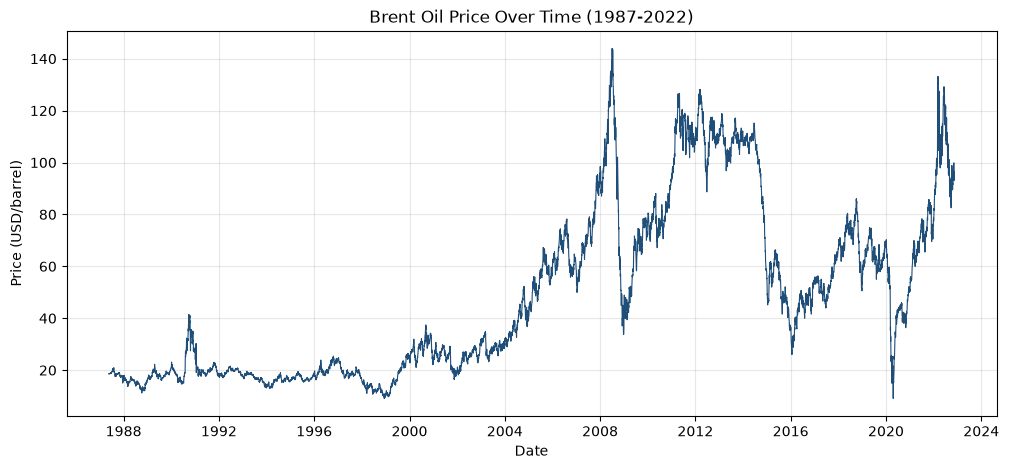

In [22]:
plt.plot(prices["Date"], prices["Price"], linewidth=0.8, color="#1F4E79")
plt.title("Brent Oil Price Over Time (1987-2022)")
plt.xlabel("Date")
plt.ylabel("Price (USD/barrel)")
plt.grid(alpha=0.3)
plt.show()

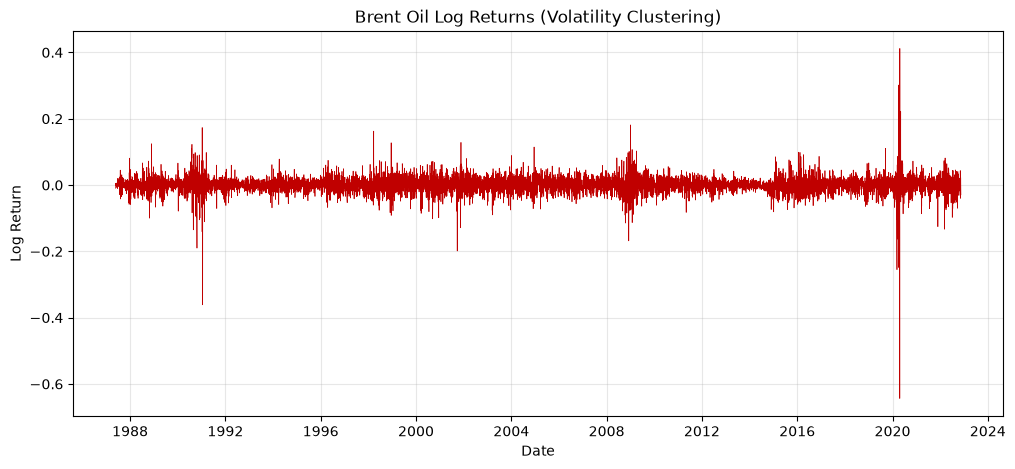

In [23]:
prices["log_return"] = np.log(prices["Price"]) - np.log(prices["Price"].shift(1))
prices_clean = prices.dropna(subset=["log_return"])

plt.plot(prices_clean["Date"], prices_clean["log_return"], linewidth=0.5, color="#C00000")
plt.title("Brent Oil Log Returns (Volatility Clustering)")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.grid(alpha=0.3)
plt.show()

In [24]:
def adf_report(series, label):
    result = adfuller(series.dropna())
    print(f"--- ADF Test: {label} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    verdict = "Stationary" if result[1] < 0.05 else "Non-stationary"
    print(f"Result: {verdict}\n")
    return result

adf_report(prices["Price"], "Raw Price Series")
adf_report(prices_clean["log_return"], "Log Returns Series")

--- ADF Test: Raw Price Series ---
ADF Statistic: -1.9939
p-value: 0.2893
Result: Non-stationary

--- ADF Test: Log Returns Series ---
ADF Statistic: -16.4271
p-value: 0.0000
Result: Stationary



(np.float64(-16.427113494485784),
 np.float64(2.4985801611434444e-29),
 28,
 8981,
 {'1%': np.float64(-3.4310783342658615),
  '5%': np.float64(-2.861861876398633),
  '10%': np.float64(-2.566941329781918)},
 np.float64(-40421.4169199348))

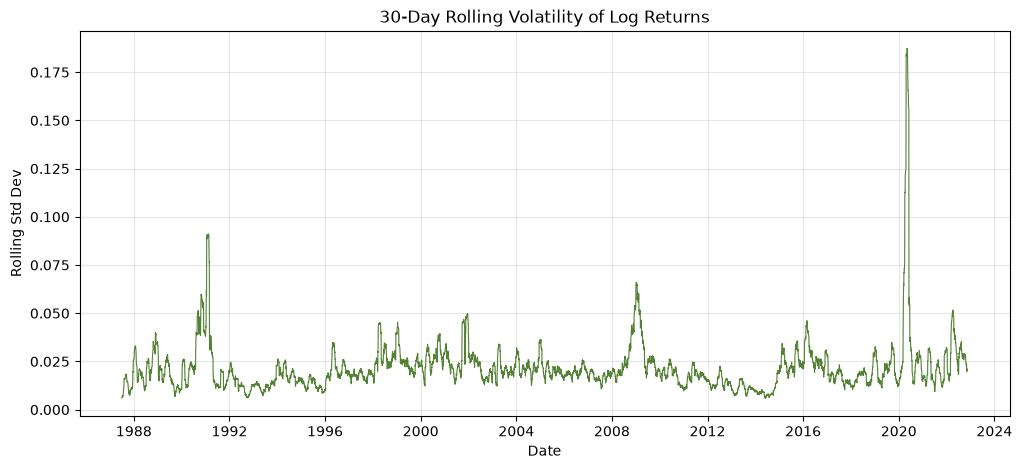

In [25]:
prices_clean = prices_clean.copy()
prices_clean["rolling_vol"] = prices_clean["log_return"].rolling(window=30).std()

plt.plot(prices_clean["Date"], prices_clean["rolling_vol"], linewidth=0.8, color="#548235")
plt.title("30-Day Rolling Volatility of Log Returns")
plt.xlabel("Date")
plt.ylabel("Rolling Std Dev")
plt.grid(alpha=0.3)
plt.show()